In [1]:
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from PIL import Image
import cv2

# Собираем данные

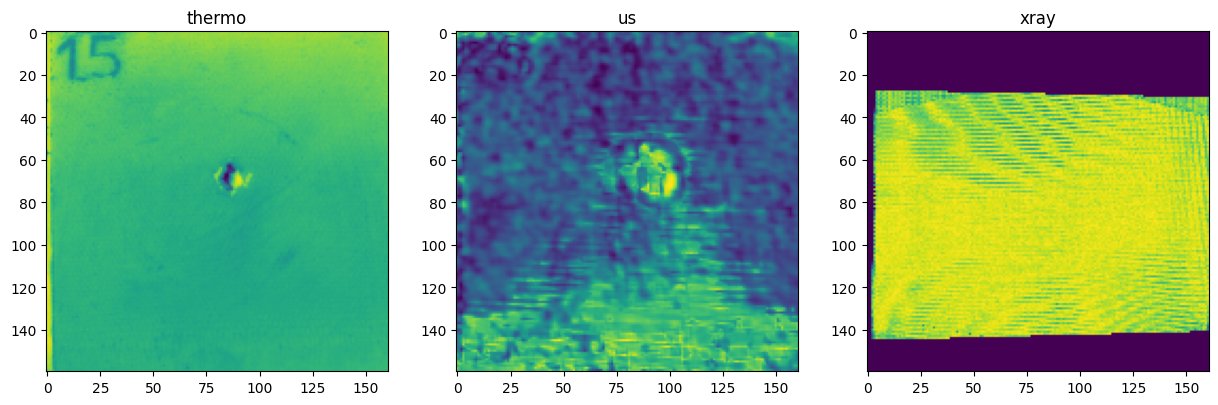

In [2]:
m = loadmat('10frames.mat')
thermo, us, xray = m['thermo'], m['us'], m['xray']
del m


plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title('thermo')
plt.imshow(thermo[:, :, 0])

plt.subplot(1, 3, 2)
plt.title('us')
plt.imshow(us[:, :, 0])

plt.subplot(1, 3, 3)
plt.title('xray')
plt.imshow(xray[:, :, 0])


In [3]:
x = np.stack([thermo, us, xray], axis=3)
x.shape

(160, 161, 10, 3)

(10, 160, 161, 3)

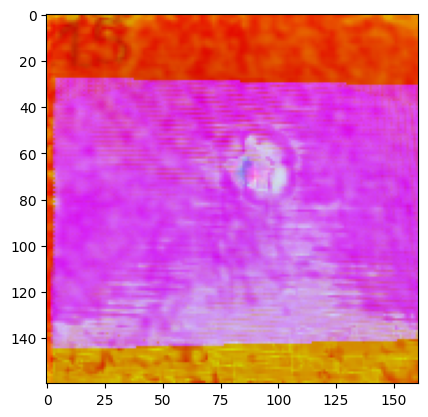

In [4]:
x = x.transpose(2, 0, 1, 3)
plt.imshow(x[0], cmap='gray')
x.shape

(160, 161, 3)

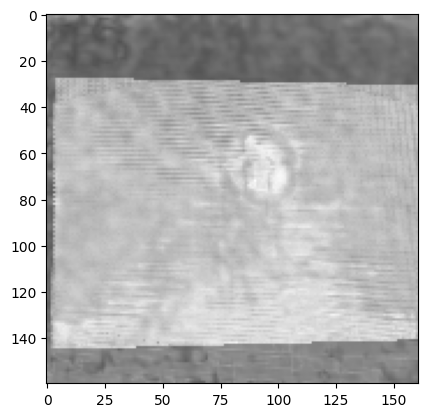

In [34]:
img = np.repeat(np.sum(x[0], axis=2, keepdims=True), repeats=3, axis=2)
img /= img.max()
img *= 255.
plt.imshow((img).astype('uint8'))
img.shape

# Помечаем дефекты

In [48]:
for i in range(10):
    img = np.repeat(np.sum(x[i], axis=2, keepdims=True), repeats=3, axis=2)
    img /= img.max()
    img *= 255.
    img = Image.fromarray(img.astype('uint8'))
    img.save(f'y/x{i}.png')

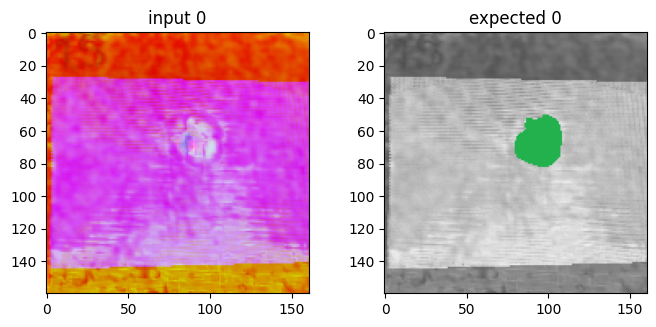

In [171]:
plt.figure(figsize=(8, 40))

for i in range(1):
    plt.subplot(10, 2, i*2+1)
    plt.title(f'input {i}')
    plt.imshow(x[i])
    
    plt.subplot(10, 2, i*2+2)
    plt.title(f'expected {i}')
    plt.imshow(np.array(Image.open(f'y/y{i}.png')))

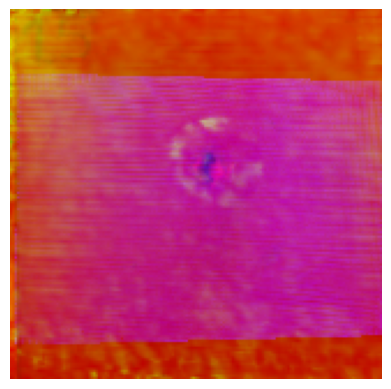

In [ ]:
plt.figure(frameon=False)
plt.axis('off')
plt.imshow(x[8])

# Создаем датасет

In [153]:
m = loadmat('10frames.mat')
thermo, us, xray = m['thermo'], m['us'], m['xray']
del m
x = np.stack([thermo, us, xray], axis=3)
x = x.transpose(2, 0, 1, 3)
x.shape

(10, 160, 161, 3)

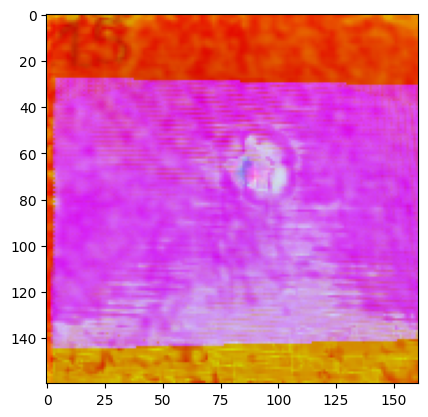

In [161]:
plt.imshow(x[0])

In [ ]:
plt.figure(figsize=(15, 10))

plt.subplot(3, 1, 1)
plt.title('thermo')
plt.plot(np.average(x[:, 90:140, 10:110, 0], axis=(1, 2)), label='nd')
plt.plot(np.average(x[:, 55:70, 80:100, 0], axis=(1, 2)), label='d')
plt.legend()

plt.subplot(3, 1, 2)
plt.title('us')
plt.plot(np.average(x[:, 90:140, 10:110, 1], axis=(1, 2)), label='nd')
plt.plot(np.average(x[:, 55:70, 80:100, 1], axis=(1, 2)), label='d')
plt.legend()

plt.subplot(3, 1, 3)
plt.title('xray')
plt.plot(np.average(x[:, 90:140, 10:110, 2], axis=(1, 2)), label='nd')
plt.plot(np.average(x[:, 55:70, 80:100, 2], axis=(1, 2)), label='d')
plt.legend()

In [3]:
y = np.zeros(shape=x.shape[:3], dtype=np.float32)
y.shape

(10, 160, 161)

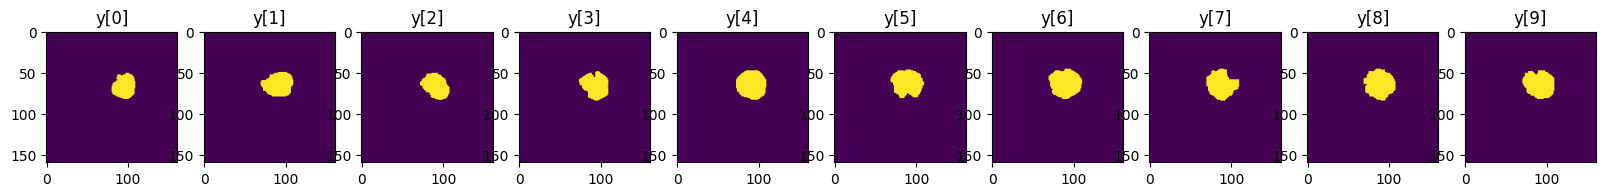

In [4]:
plt.figure(figsize=(20, 5))
for img in range(10):
    dm = np.array(Image.open(f'y/y{img}.png'))
    y[img][dm[..., 0] < dm[..., 1]] = 1

    plt.subplot(1, 10, img+1)
    plt.title(f'y[{img}]')
    plt.imshow(y[img])

In [ ]:
def rotate_image(image, angle):
    image_center = tuple(np.array(image.shape[1::-1]) / 2)
    rot_mat = cv2.getRotationMatrix2D(image_center, angle, 1.0)
    result = cv2.warpAffine(image, rot_mat, image.shape[1::-1], flags=cv2.INTER_LINEAR)
    return result

In [6]:
x_list, y_list = [], []

for i in range(10):
    x_list.append(x[i])
    x_list.append(
        cv2.rotate(x[i], cv2.ROTATE_180)
    )
    
    y_list.append(y[i])
    y_list.append(
        cv2.rotate(y[i], cv2.ROTATE_180)
    )

    x_refl = cv2.flip(x[i], 0)
    y_refl = cv2.flip(y[i], 0)
    
    x_list.append(x_refl)
    x_list.append(
        cv2.rotate(x_refl, cv2.ROTATE_180)
    )
    
    y_list.append(y_refl)
    y_list.append(
        cv2.rotate(y_refl, cv2.ROTATE_180)
    )

    for angle in [10, 20, 30, 40, 50, 60, 70, 80]:
        x_list.append(
            rotate_image(x[i], angle)
        )
        y_list.append(
            rotate_image(y[i], angle)
        )
        x_list.append(
            rotate_image(x_refl, angle)
        )
        y_list.append(
            rotate_image(y_refl, angle)
        )

In [7]:
X, Y = np.array(x_list, dtype=np.float32), np.array(y_list, dtype=np.float32)
X.shape, Y.shape

((200, 160, 161, 3), (200, 160, 161))

In [8]:
np.save('X.npy', X)
np.save('Y.npy', Y)

# Модель

In [2]:
X, Y = np.load('X.npy'), np.load('Y.npy')
idxs = np.random.permutation(X.shape[0])

X = X[idxs].copy()
Y = Y[idxs].copy()

Y = np.array([Y, 1-Y], dtype=Y.dtype).transpose(1, 2, 3, 0)
print(Y.shape)

x, y = X[3:].copy(), Y[3:].copy()
x_val, y_val = X[:3].copy(), Y[:3].copy()

(200, 160, 161, 2)


In [ ]:
for i in range(0, 10):
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title(f'input {i}')
    plt.imshow((x[i]*255).astype('uint8'))
    
    plt.subplot(1, 2, 2)
    plt.title(f'expected {i}')
    plt.imshow(np.append(y[i, ..., 0], y[i, ..., 1], axis=0))

In [5]:
del X, Y

In [ ]:
def dense_res_block(prev, filters=16, kernel=3, layers=10, dropout_rate=0.1):
    for _ in range(layers):
        curr = keras.layers.Conv2D(filters, kernel, padding='same', activation='relu')(prev) + prev
        prev = curr
    return curr

def create_model():
    input_x = keras.layers.Input(shape=(None, None, 3))

    x = keras.layers.Conv2D(24, 3, padding='same', activation='relu')(input_x)

    x = dense_res_block(x, filters=24, kernel=7, layers=20, dropout_rate=0)

    output_x = keras.layers.Conv2D(filters=2, kernel_size=5, padding='same', activation='softmax')(x)

    return keras.models.Model(input_x, output_x)

model = create_model()
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='binary_crossentropy')
#model.summary()

In [110]:
model = keras.models.load_model('model.keras')
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001/100), loss='binary_crossentropy')
#model.summary()

In [9]:
print('x: ', x.shape)
print('y: ', y.shape)
print('x_val: ', x_val.shape)
print('y_val: ', y_val.shape)

x:  (197, 160, 161, 3)
y:  (197, 160, 161)
x_val:  (3, 160, 161, 3)
y_val:  (3, 160, 161)


In [138]:
history = model.fit(x=x, y=y, validation_data=(x_val, y_val), batch_size=50, epochs=50) # batch_size=50, 197 -> 17s/epoch

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 18s 4s/step - loss: 0.0464 - val_loss: 0.0324
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 17s 4s/step - loss: 0.0461 - val_loss: 0.0323
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 17s 4s/step - loss: 0.0459 - val_loss: 0.0324
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 17s 4s/step - loss: 0.0458 - val_loss: 0.0320
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 17s 4s/step - loss: 0.0455 - val_loss: 0.0318
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 17s 4s/step - loss: 0.0455 - val_loss: 0.0316
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 17s 4s/step - loss: 0.0452 - val_loss: 0.0317
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 17s 4s/step - loss: 0.0451 - val_loss: 0.0317
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 17s 4s/step - loss: 0.0452 - val_loss: 0.0313
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 17s 4s/step - loss: 0.0451 - val_loss: 0.0315
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 17s 4s/step - loss: 0.0447 - val_loss: 0.0308
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 17s 4s/step - loss: 0.0444 - val_loss: 0.0306
Epoch 13/50
4

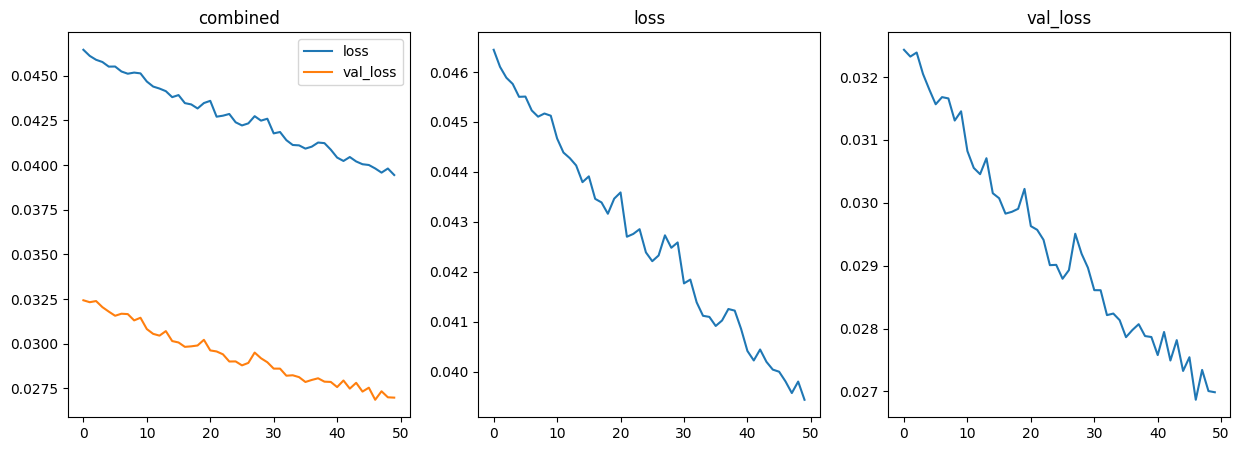

In [150]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title('combined')
plt.plot(history.history['loss'][:], label='loss')
plt.plot(history.history['val_loss'][:], label='val_loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.title('loss')
plt.plot(history.history['loss'][:])

plt.subplot(1, 3, 3)
plt.title('val_loss')
plt.plot(history.history['val_loss'][:])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


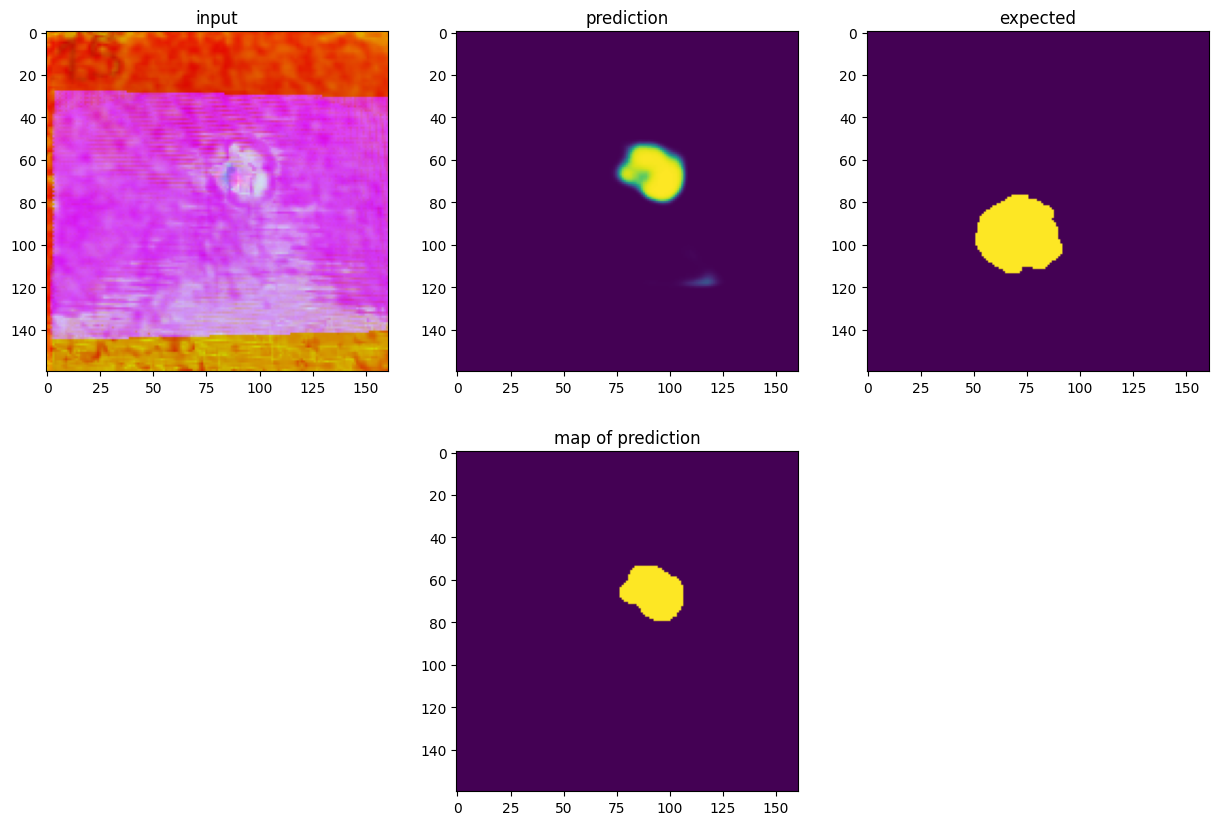

In [ ]:
i = 0 # < 3
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.title('input')
plt.imshow(x_val[i])

pred = model.predict(  [x_val[i:i+1]]  )[0]

plt.subplot(2, 3, 2)
plt.title('prediction')
#plt.imshow(  np.log(pred[..., 0]+.0001)  )
plt.imshow(pred[..., 0])

plt.subplot(2, 3, 3)
plt.title('expected')
plt.imshow(y_val[i, ..., 0])

plt.subplot(2, 3, 5)
plt.title('map of prediction')
plt.imshow(1-np.argmax(pred, axis=-1))

In [154]:
model.save('model.keras')